Example of how to parse the files and load data in dataframes.

In [1]:
#%pip install matplotlib

import os
import matplotlib.pyplot as plt
import matplotlib
import math
matplotlib.use('TkAgg')
%matplotlib notebook
%matplotlib inline


In [2]:
data_path = os.getcwd() + os.sep + 'data'
print(data_path)

C:\Users\Filip\Documents\Examensarbete\data


In [3]:
# Loading data functions
def loader(data_path, blacklist):
    data = []
    all_data_csv = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
    for name in os.listdir(data_path):
        if name != '.DS_Store' and 'csv' not in name and 'txt' not in name:
            print('---------------------------------------------')
            print("Loading walking data for subject: ",name)
            new_path = data_path + os.sep + name
            for name_in in os.listdir(new_path):
                if name_in != '.DS_Store' and name_in not in blacklist:
                    print("Loading test: ", name_in)
                    motion_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'motion.csv')
                    position_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'positions.csv')
                    orientation_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'orientation.csv')
                    steps_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'steps.csv')
                    event_csv = pd.read_csv(new_path + os.sep + name_in + os.sep + 'events.csv')

                    anon_test = walking_test(
                        name_in, event_csv,
                        motion_csv,
                        orientation_csv,
                        position_csv,
                        steps_csv
                    )
                    data.append(anon_test)

    return data, all_data_csv

class walking_test:
    def __init__(self, filename, events, motion, orientation, positions, steps): #
        self.filename = filename
        self.events = events
        self.motion = motion
        self.orientation = orientation
        self.positions = positions
        self.steps = steps

In [4]:
#%pip install pandas

import pandas as pd

# Uploading metadata and determining blacklist
metadata = pd.read_csv(data_path + os.sep + 'metadata_tracks.csv')
print("Metadata columns: ", metadata.columns)

noIMU = metadata[metadata['hasMotion'] == False]['testName'].tolist()
noGPS = metadata[metadata['hasGNSS'] == False]['testName'].tolist()
blacklist = noIMU + noGPS
print("Blacklist: ", blacklist)

Metadata columns:  Index(['subject', 'testID', 'testName', 'isPatient', 'distanceReference',
       'hasMotion', 'hasGNSS', 'device', 'distanceByApp', 'totSteps',
       'path curvature', 'total_gaps_time_inertial', 'total_gaps_time_gnss',
       'gt_type', 'country', 'gnss_anonimized', 'duration [s]', 'fs_acc',
       'fs_gnss', 'fs_steps', 'average_walking_speed', 'smartphone_position',
       'smartphone app'],
      dtype='object')
Blacklist:  ['0_0', '0_1', '0_2', '0_3', '0_4', '0_5', '0_6', '0_7', '0_8', '0_9', '0_10', '0_11', '0_12', '0_13', '0_14', '1_0', '1_1', '1_2', '1_3', '1_4', '1_5', '1_6', '1_7', '1_8', '1_9', '2_0', '2_1', '2_2', '2_3', '2_4', '2_5', '2_6', '2_7', '2_8', '2_9', '3_0', '3_5', '3_6', '3_7', '3_8', '3_9', '9_0', '9_1', '9_2', '9_3', '9_4', '9_5', '9_6', '9_7', '9_8', '9_9', '9_10', '15_0', '15_1', '15_2', '15_3', '15_4']


In [5]:
# Loading data
selection, info_all_tests = loader(data_path, blacklist=blacklist)
print("Successfully loaded data")

---------------------------------------------
Loading walking data for subject:  subject_0
---------------------------------------------
Loading walking data for subject:  subject_1
---------------------------------------------
Loading walking data for subject:  subject_10
Loading test:  10_0
Loading test:  10_1
Loading test:  10_10
Loading test:  10_11
Loading test:  10_12
Loading test:  10_13
Loading test:  10_14
Loading test:  10_15
Loading test:  10_16
Loading test:  10_17
Loading test:  10_2
Loading test:  10_3
Loading test:  10_4
Loading test:  10_5
Loading test:  10_6
Loading test:  10_7
Loading test:  10_8
Loading test:  10_9
---------------------------------------------
Loading walking data for subject:  subject_11
Loading test:  11_0
Loading test:  11_1
Loading test:  11_10
Loading test:  11_11
Loading test:  11_12
Loading test:  11_13
Loading test:  11_14
Loading test:  11_15
Loading test:  11_2
Loading test:  11_3
Loading test:  11_4
Loading test:  11_5
Loading test:  11_6


In [6]:
# Example of what a walking test contains:
print("Selection[0] contains: ")
print("Filename: ", selection[0].filename)
#Events
print("Events: ", selection[0].events.head())
#Motion
print("Motion: ", selection[0].motion.head())
#Orientation
print("Orientation: ", selection[0].orientation.head())
#Positions
print("Positions: ", selection[0].positions.head())
#Steps
print("Steps: ", selection[0].steps.head())

Selection[0] contains: 
Filename:  10_0
Events:     Unnamed: 0  signalStart  testStart        testEnd
0           0            0     1481.0  361167.000055
Motion:     Unnamed: 0     ms  accelX  accelY  accelZ  accelWithGX  accelWithGY  \
0           0  178.0    -0.1     0.0     0.2         -0.2          3.2   
1           1  192.0    -0.1     0.0     0.3         -0.2          3.2   
2           2  200.0    -0.1    -0.1     0.3         -0.3          3.1   
3           3  218.0    -0.1    -0.2     0.4         -0.2          2.9   
4           4  234.0    -0.1    -0.2     0.4         -0.3          2.9   

   accelWithGZ  rotRateAlpha  rotRateBeta  rotRateGamma  interval  
0          9.4          -2.6          0.8           3.3        16  
1          9.4          -2.6          0.8           3.3        16  
2          9.6          -2.8         -1.4           3.4        16  
3          9.7          -1.6         -2.1           2.4        16  
4          9.8           0.5         -3.4          

In [7]:
#Saras code
def crowDist(point1, point2):
    lat1 = point1.latitude
    lat2 = point2.latitude
    lon1 = point1.longitude
    lon2 = point2.longitude
    R = 6371  # km
    dLat = math.radians(lat2 - lat1)
    dLon = math.radians(lon2 - lon1)
    lat1 = math.radians(lat1)
    lat2 = math.radians(lat2)
    a = math.sin(dLat / 2) * math.sin(dLat / 2) + \
        math.sin(dLon / 2) * math.sin(dLon / 2) * math.cos(lat1) * math.cos(lat2)
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    d = R * c
    return d * 1000

In [8]:
for i, test in enumerate(selection):
    print(f"Attributes of selection[{i}]:")
    print(vars(test))  # or print(test.__dict__)
    print("-" * 50)

Attributes of selection[0]:
{'filename': '10_0', 'events':    Unnamed: 0  signalStart  testStart        testEnd
0           0            0     1481.0  361167.000055, 'motion':        Unnamed: 0        ms  accelX  accelY  accelZ  accelWithGX  accelWithGY  \
0               0     178.0    -0.1     0.0     0.2         -0.2          3.2   
1               1     192.0    -0.1     0.0     0.3         -0.2          3.2   
2               2     200.0    -0.1    -0.1     0.3         -0.3          3.1   
3               3     218.0    -0.1    -0.2     0.4         -0.2          2.9   
4               4     234.0    -0.1    -0.2     0.4         -0.3          2.9   
...           ...       ...     ...     ...     ...          ...          ...   
21507       21507  361086.0     0.1    -0.1    -0.1         -0.4          4.8   
21508       21508  361103.0     0.1     0.1    -0.4         -0.4          4.8   
21509       21509  361120.0     0.1     0.1    -0.2         -0.4          4.9   
21510       21

Total distance traveled for 10_0: 443.74 meters
    time_s  distance_m  delta_time_s  speed_mps
0    0.000    0.000000           NaN        NaN
1    1.483    3.168537         1.483   2.136573
2    2.707    3.992368         1.224   3.261738
3    3.704    1.953551         0.997   1.959429
4    4.707    1.675395         1.003   1.670384
..     ...         ...           ...        ...
95  95.710    1.308786         1.020   1.283124
96  96.704    1.185185         0.994   1.192339
97  97.698    2.096551         0.994   2.109206
98  98.688    0.912673         0.990   0.921892
99  99.702    1.055236         1.014   1.040667

[100 rows x 4 columns]


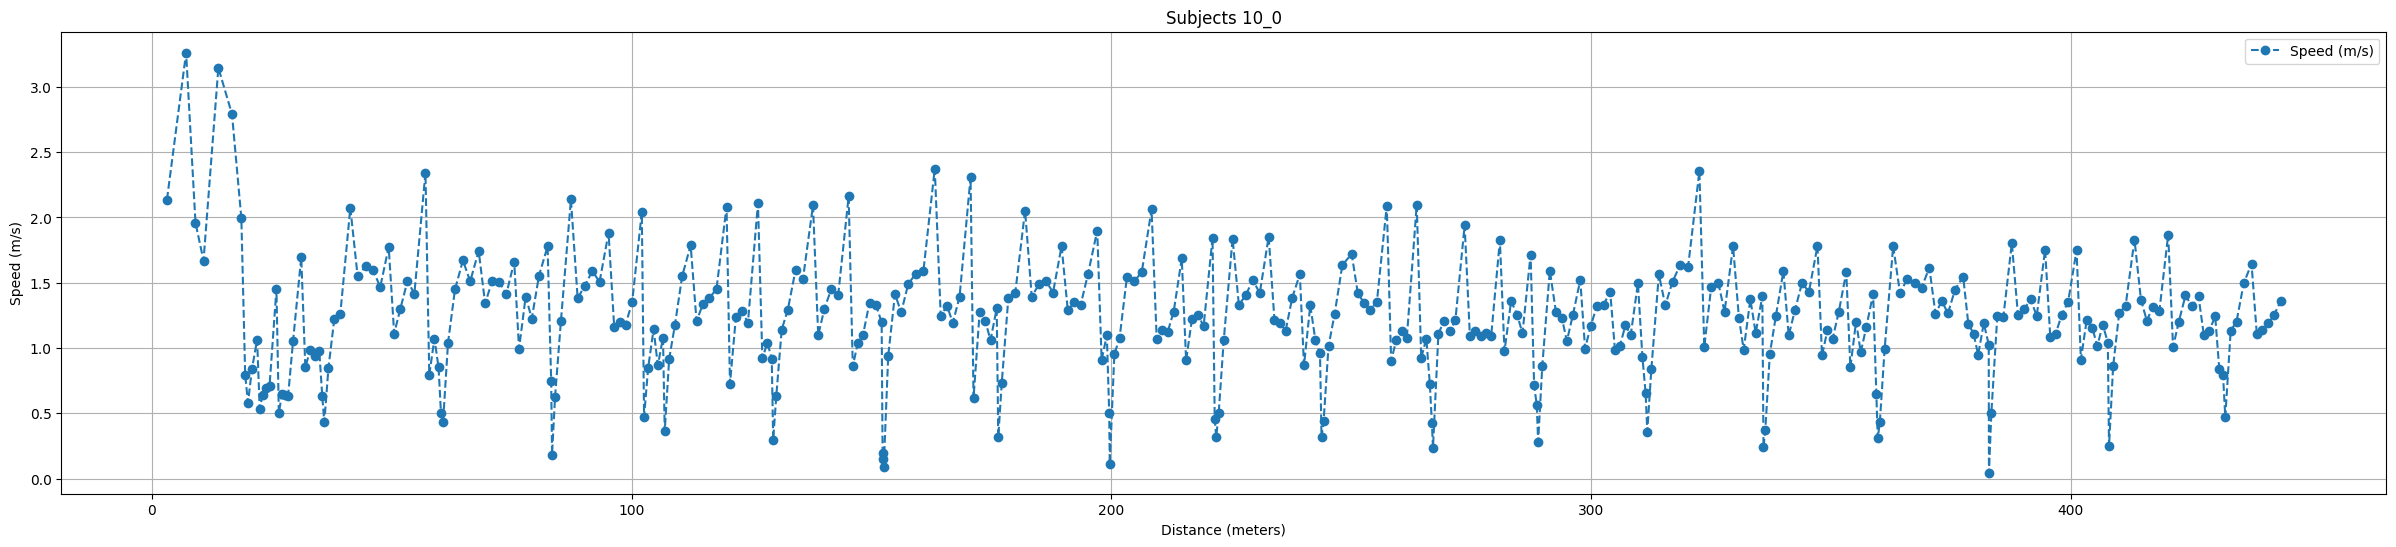

In [9]:
import math

all_tests = []

for select in selection:
    all_tests.append(select.filename)
   
   

# Function to filter tests by subject name
def filter_tests_by_subject(selection, subject_name):
    return [test for test in selection if test.filename.startswith(subject_name)]

# Using the function to filter tests
subject_name = '10_0'  # Replace with the desired subject name
filtered_selection = filter_tests_by_subject(selection, subject_name)

# Proceed with the filtered selection
for test in filtered_selection:
    positions_data = test.positions.copy()  # Important to copy the data to avoid modifying the original

    # Convert time to seconds from start
    positions_data['time_s'] = (positions_data['ms'] - positions_data['ms'].min()) / 1000

    # Calculate distance between points (protects against index errors)
    distances = [0] + [
        crowDist(positions_data.iloc[i-1], positions_data.iloc[i])
        for i in range(1, len(positions_data))
    ]
    positions_data['distance_m'] = distances

    # Total distance
    total_distance = positions_data['distance_m'].sum()
    print(f"Total distance traveled for {test.filename}: {total_distance:.2f} meters")

    # Calculate time difference between measurement points
    positions_data['delta_time_s'] = positions_data['time_s'].diff()

    # Protect against division by small values or zero
    min_time_threshold = 0.1  # Minimum allowed time difference in seconds
    positions_data['delta_time_s'] = positions_data['delta_time_s'].clip(lower=min_time_threshold)

    # Calculate speed in m/s
    positions_data['speed_mps'] = positions_data['distance_m'] / positions_data['delta_time_s']

    #Show the first 10 rows of data
    print(positions_data[['time_s', 'distance_m', 'delta_time_s', 'speed_mps']].head(100))

    # Plot for speed vs distance
    plt.figure(figsize=(30, 6))
    plt.plot(positions_data['distance_m'].cumsum(), positions_data['speed_mps'], marker='o', linestyle='--', label='Speed (m/s)')
    plt.xlabel('Distance (meters)')
    plt.ylabel('Speed (m/s)')
    plt.title(f"Subjects {test.filename}")
    plt.legend()
    plt.grid()
    plt.show()

Epoch 1/50


C:\Users\Filip\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.2553
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1295
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.1067
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0885
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0716
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0625
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0565
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0564
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0515
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0524
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0588
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0561
Epoch 13/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0583
Epoch 14/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0489
Epoch 15/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0541
Epoch 16/50
11/

,Time (s),Actual Distance (m),Predicted Distance (m)
0,0,2.136573,0.962085
1,1,5.398311,2.052237
2,2,7.357740,3.186221
3,3,9.028123,4.316498
4,4,12.174614,5.397526
...,...,...,...
355,355,437.120674,452.811523
356,356,438.261765,454.058624
357,357,439.450685,455.306732
358,358,440.705422,456.556274


Mean Squared Error (MSE): 55.90
Root Mean Squared Error (RMSE): 7.48


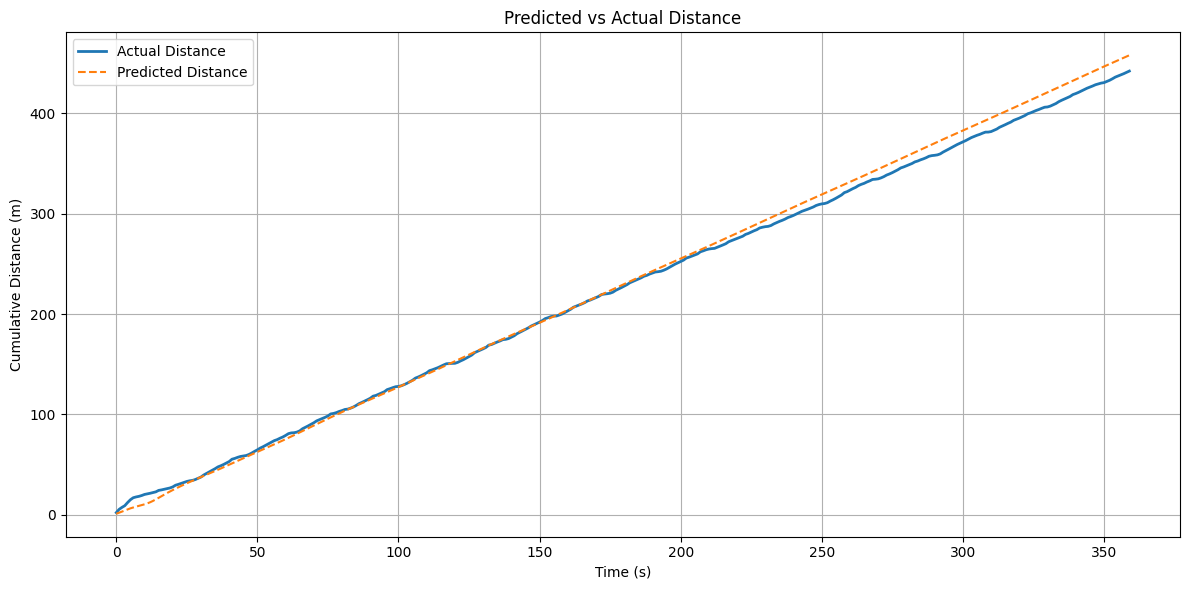

In [15]:
#%pip install tensorflow

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

positions_data_full = positions_data.copy()

# Select relevant features and remove missing values
positions_data = positions_data[['latitude', 'longitude', 'altitude', 'speed_mps']].dropna()

# Scale data to the range [0, 1] for better training performance
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(positions_data.values)

# Create time series sequences for GRU input
def create_dataset(data, time_step=10):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, :])
    return np.array(X), np.array(y)

time_step = 10  # Number of previous time steps to consider
X, y = create_dataset(scaled_data, time_step)

# Reshape input for GRU: (samples, time_steps, features)
X = X.reshape(X.shape[0], X.shape[1], X.shape[2])

# Build GRU model with two stacked layers
model = Sequential()
model.add(GRU(units=360, return_sequences=True, input_shape=(X.shape[1], X.shape[2])))
model.add(GRU(units=360))
model.add(Dense(units=4))  # Output: latitude, longitude, altitude, speed
#model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error') #MSE
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_absolute_error') #MAE

# Train the model
model.fit(X, y, epochs=50, batch_size=32)

# Predict 6MWT
prediction_seconds = 360

# Use the last known sequence as input seed
input_seq = scaled_data[-time_step:].reshape(1, time_step, scaled_data.shape[1])
predictions = []

# Iteratively generate predictions and feed them back into the model
for _ in range(prediction_seconds):
    pred = model.predict(input_seq, verbose=0)[0]
    predictions.append(pred)
    new_input = np.append(input_seq[0, 1:, :], [pred], axis=0)
    input_seq = new_input.reshape(1, time_step, scaled_data.shape[1])

# Convert predictions back to original scale
predictions = np.array(predictions)
inverted_predictions = scaler.inverse_transform(predictions)

# Extract speed column (index 3) and compute cumulative distance
delta_t = 1  # Assuming 1 second between each sample
predicted_speeds = inverted_predictions[:, 3]
predicted_distances = np.cumsum(predicted_speeds * delta_t)

# Trimma faktiska värden till samma längd som prediktionerna (360 sekunder)
actual_speeds = positions_data['speed_mps'].values[:prediction_seconds]
actual_distances = np.cumsum(actual_speeds * delta_t)

# Säkerställ att båda arrayerna har samma längd
min_len = min(len(actual_distances), len(predicted_distances))
actual_distances = actual_distances[:min_len]
predicted_distances = predicted_distances[:min_len]

# Räkna MSE och RMSE
mse = mean_squared_error(actual_distances, predicted_distances)
rmse = math.sqrt(mse)

# Skapa jämförelsetabell
comparison_df = pd.DataFrame({
    'Time (s)': np.arange(min_len),
    'Actual Distance (m)': actual_distances,
    'Predicted Distance (m)': predicted_distances
})

# Visa tabellen
from IPython.display import display
display(comparison_df)

# Skriv ut felmått
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

# Plot jämförelse
plt.figure(figsize=(12, 6))
plt.plot(actual_distances, label='Actual Distance', linewidth=2)
plt.plot(predicted_distances, label='Predicted Distance', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Cumulative Distance (m)')
plt.title('Predicted vs Actual Distance')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [27]:
if hasattr(metadata, 'distanceReference'):
    print(f"Ground truth distance: {metadata.distanceReference}")


Ground truth distance: 0      623
1      598
2      584
3      577
4      590
      ... 
198    317
199    365
200    452
201    461
202    517
Name: distanceReference, Length: 203, dtype: int64


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0484 - val_loss: 0.0444
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0454 - val_loss: 0.0497
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0479 - val_loss: 0.0476
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0518 - val_loss: 0.0484
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0487 - val_loss: 0.0453
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0436 - val_loss: 0.0438
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0462 - val_loss: 0.0439
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0465 - val_loss: 0.0438
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0445 - val_loss: 0.0418
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0434 - val_loss: 0.0424
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0433 - val_loss: 0.0431
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0427 - val_loss: 0.0462
E

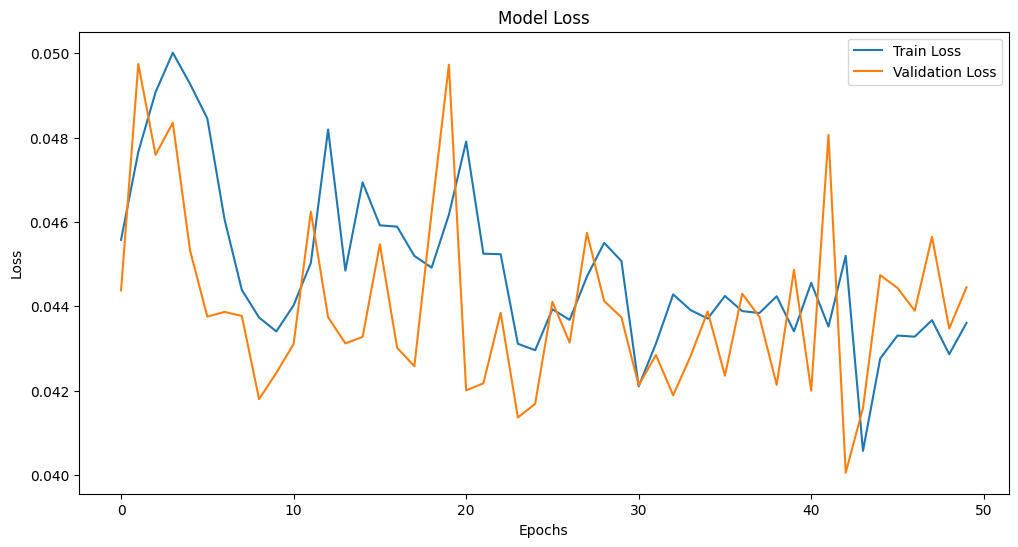

In [16]:
# Train the model and store the training history
history = model.fit(X, y, validation_split=0.2, epochs=50, batch_size=32)

# Visualize the training process
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()



# Loopa alla subject och gör ett dataset att visa:

In [29]:
# Antag att test.distanceReference är i meter och representerar ground truth
ground_truth_distance = metadata.distanceReference


print("Predicted distance: ", predicted_distances[-1])
print("Ground truth distance: ", ground_truth_distance)
print("Difference (pred - truth): ", predicted_distances[-1] - ground_truth_distance)


Predicted distance:  457.80762
Ground truth distance:  0      623
1      598
2      584
3      577
4      590
      ... 
198    317
199    365
200    452
201    461
202    517
Name: distanceReference, Length: 203, dtype: int64
Difference (pred - truth):  0     -165.192383
1     -140.192383
2     -126.192383
3     -119.192383
4     -132.192383
          ...    
198    140.807617
199     92.807617
200      5.807617
201     -3.192383
202    -59.192383
Name: distanceReference, Length: 203, dtype: float64


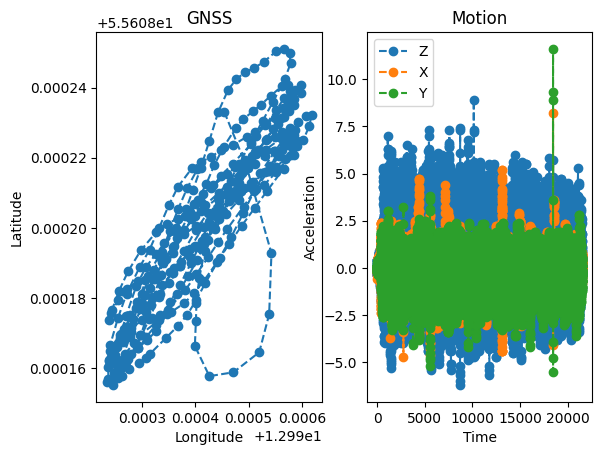

In [13]:
# Example of how to plot position data
fig = plt.figure()
ax = fig.add_subplot(121)
ax.plot(selection[0].positions['longitude'], selection[0].positions['latitude'],'o--')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GNSS')

ax = fig.add_subplot(122)
ax.plot(selection[0].motion['accelZ'],'o--', label='Z')
ax.plot(selection[0].motion['accelX'],'o--', label='X')
ax.plot(selection[0].motion['accelY'],'o--', label='Y')
ax.set_xlabel('Time')
ax.set_ylabel('Acceleration')
ax.legend()
ax.set_title('Motion')
plt.show()
